In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

PermissionError: [Errno 13] Permission denied: 'Housing.csv'

In [3]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\sumit\OneDrive\Desktop\HousePricePrediction_SumitBanerjee
['.ipynb_checkpoints', 'analysis.ipynb', 'charts', 'Housing.csv']


In [4]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
analysis.ipynb
charts
Housing.csv


In [5]:
import os

print(os.path.isfile("Housing.csv"))
print(os.path.isdir("Housing.csv"))

False
True


In [6]:
import os

print(os.listdir("Housing.csv"))

['Housing.csv']


In [7]:
df = pd.read_csv("Housing.csv/Housing.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
df.shape

(545, 13)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [11]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

print(df.shape)

(545, 13)


In [14]:
df.select_dtypes(include='object').columns

C:\Users\sumit\AppData\Local\Temp\ipykernel_20840\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [15]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [16]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [17]:
X = df_encoded.drop("price", axis=1)

y = df_encoded["price"]

print(X.shape)
print(y.shape)

(545, 13)
(545,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [22]:
mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

r2_rf = r2_score(y_test, pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [23]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


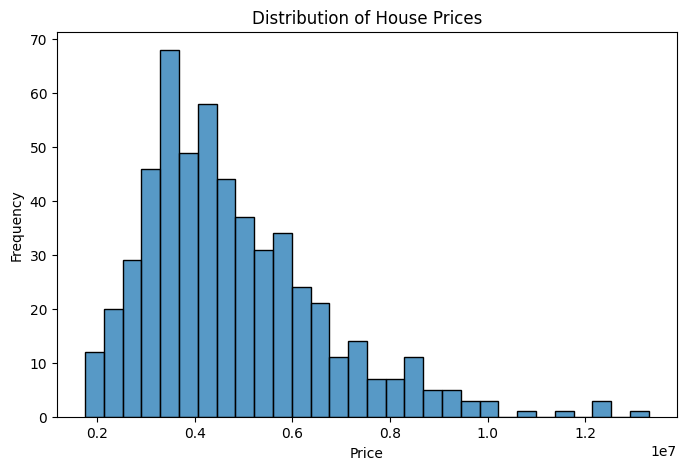

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

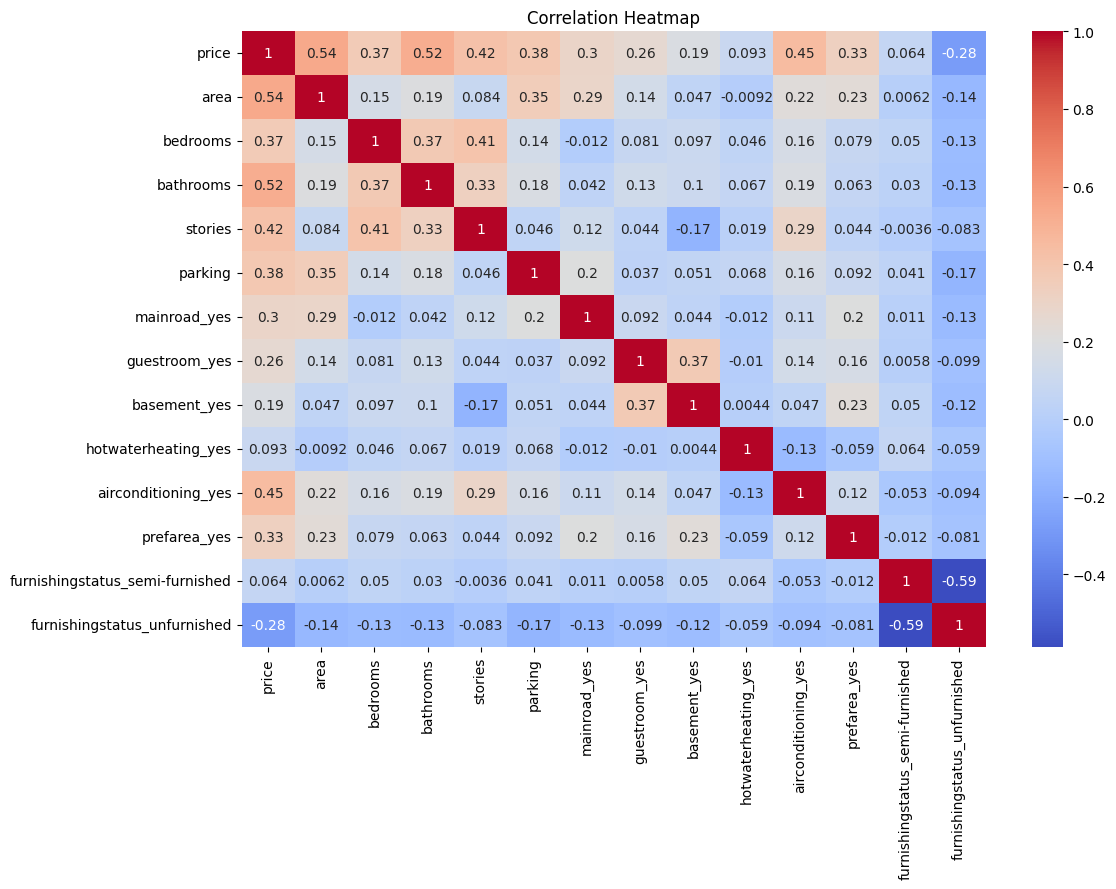

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

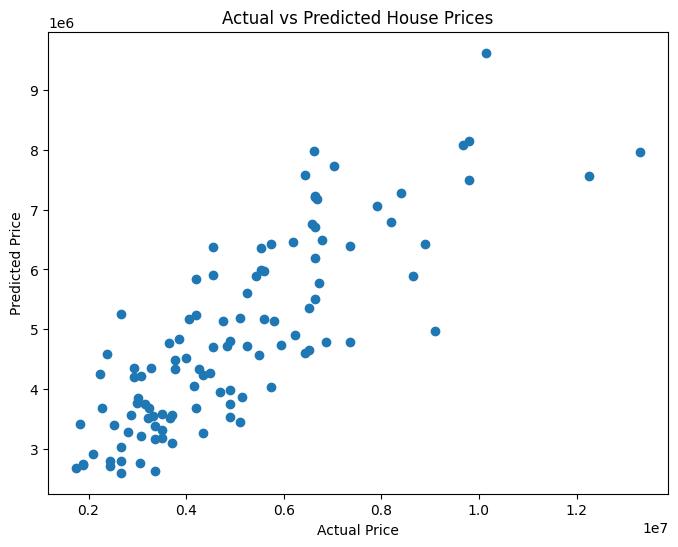

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [28]:
top_features = importance.sort_values(
    by="Importance",
    ascending=False
)

top_features.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


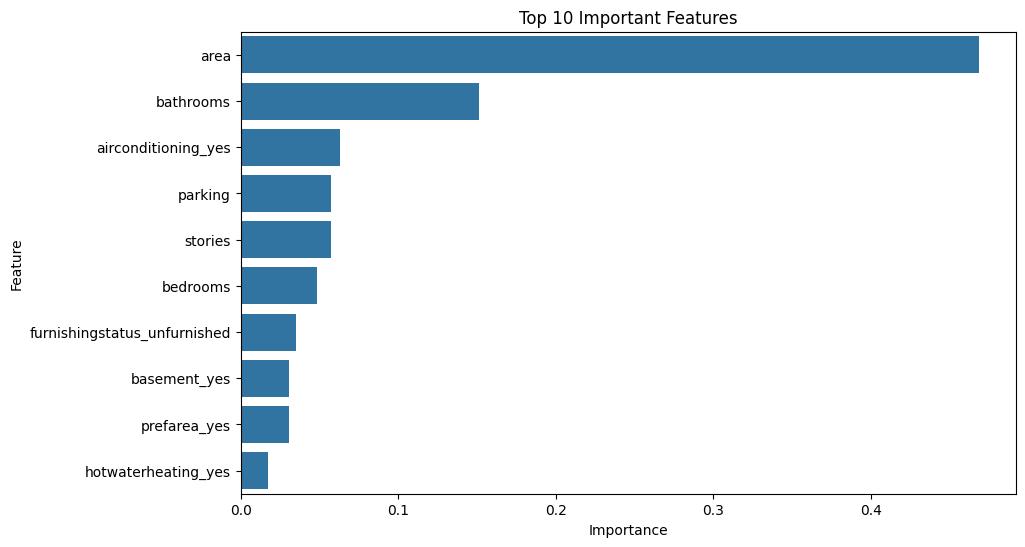

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig("charts/feature_importance.png")

plt.show()

Conclusion

1. Area is the most important factor affecting house prices.
2. Bathrooms, Air Conditioning and Parking also have significant influence.
3. Linear Regression outperformed Random Forest on this dataset.
4. The model explains approximately 65% of the variation in house prices.
5. Real estate companies should focus on larger properties with modern amenities.